<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/DCGAN-WK-8.2A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training DCGAN on Circle Shapes...
Epoch [0/600] | Loss D: 1.0215 | Loss G: 1.4814
Epoch [200/600] | Loss D: 0.3413 | Loss G: 3.8283
Epoch [400/600] | Loss D: 0.0133 | Loss G: 2.8779

Generated Results:


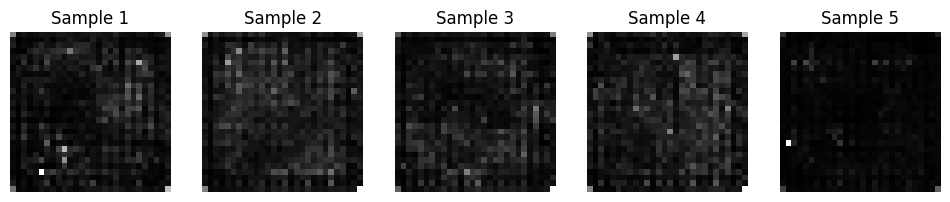

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import cv2

# ---------------------------------------------------------
# 1. GENERATE SYNTHETIC "SHAPES" DATA (Circles)
# ---------------------------------------------------------
def get_shape_data(n=1000):
    images = []
    for _ in range(n):
        img = np.zeros((28, 28), dtype=np.float32)
        # Draw a random white circle
        center = (np.random.randint(5, 23), np.random.randint(5, 23))
        radius = np.random.randint(3, 8)
        cv2.circle(img, center, radius, 1.0, -1)
        images.append(img)

    # Reshape for PyTorch: (Batch, Channel, Height, Width)
    data = torch.tensor(np.array(images)).unsqueeze(1)
    return data + torch.randn_like(data) * 0.05 # Add noise

# ---------------------------------------------------------
# 2. DEFINE THE DCGAN
# ---------------------------------------------------------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(100, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Sigmoid() # Keeps pixel values between 0 and 1
        )
    def forward(self, x):
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.main(x).view(-1, 1)

# Initialization
netG = Generator()
netD = Discriminator()
optG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# ---------------------------------------------------------
# 3. TRAINING LOOP
# ---------------------------------------------------------
epochs = 600
batch_size = 32

print("Training DCGAN on Circle Shapes...")
for epoch in range(epochs):
    # Train Discriminator
    netD.zero_grad()
    real_imgs = get_shape_data(batch_size)
    lossD_real = criterion(netD(real_imgs), torch.ones(batch_size, 1))

    noise = torch.randn(batch_size, 100, 1, 1)
    fake_imgs = netG(noise)
    lossD_fake = criterion(netD(fake_imgs.detach()), torch.zeros(batch_size, 1))

    (lossD_real + lossD_fake).backward()
    optD.step()

    # Train Generator
    netG.zero_grad()
    lossG = criterion(netD(fake_imgs), torch.ones(batch_size, 1))
    lossG.backward()
    optG.step()

    if epoch % 200 == 0:
        print(f"Epoch [{epoch}/{epochs}] | Loss D: {lossD_real.item():.4f} | Loss G: {lossG.item():.4f}")

# ---------------------------------------------------------
# 4. FINAL OUTPUT
# ---------------------------------------------------------
print("\nGenerated Results:")
with torch.no_grad():
    noise = torch.randn(5, 100, 1, 1)
    samples = netG(noise)

plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(samples[i].squeeze(), cmap='gray')
    plt.title(f"Sample {i+1}")
    plt.axis('off')
plt.show()